[Markdown Cell]
# 1. Introduction & Theoretical Background

Emotion classification is a core task in affective NLP where a model assigns a discrete emotion label (for example, anger, joy, sadness) to a text. It supports applications such as mental health monitoring, customer support triage, and social media analytics. The task is challenging because emotions can be subtle, context dependent, and expressed with figurative language.

## Why Transformers?
Text is sequential, but long range dependencies are often easier to model with self attention than with recurrence. Transformers process all tokens in parallel and let each token attend to every other token, enabling richer context mixing and more stable gradient flow.

## Self Attention Intuition and Equations
Self attention builds a context aware representation of each token using queries, keys, and values. Given token embeddings $X$, we compute:

$$
Q = XW_Q, \quad K = XW_K, \quad V = XW_V
$$
$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Multi head attention runs several attention heads in parallel, each learning different relationships, and then concatenates them. Because Transformers lack recurrence, we add positional embeddings so the model can learn word order.

In the following sections, we build a Transformer based emotion classifier in TensorFlow and Keras, including data loading, preprocessing, model design, Hyperband tuning, and evaluation with report quality visualizations.

[Markdown Cell]
# 2. Data Loading & Exploratory Data Analysis (EDA)

We use the `mteb/emotion` dataset hosted on Hugging Face Datasets. This dataset provides short texts labeled with emotion categories. A critical first step is to explore the dataset structure and class distribution, because imbalance can bias training and evaluation.

We will:
- Load the dataset.
- Inspect available splits.
- Map numeric labels to human readable names.
- Plot class distribution with Seaborn.
- Compute average word counts to understand typical sequence lengths.

In [4]:
!pip install keras_tuner

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


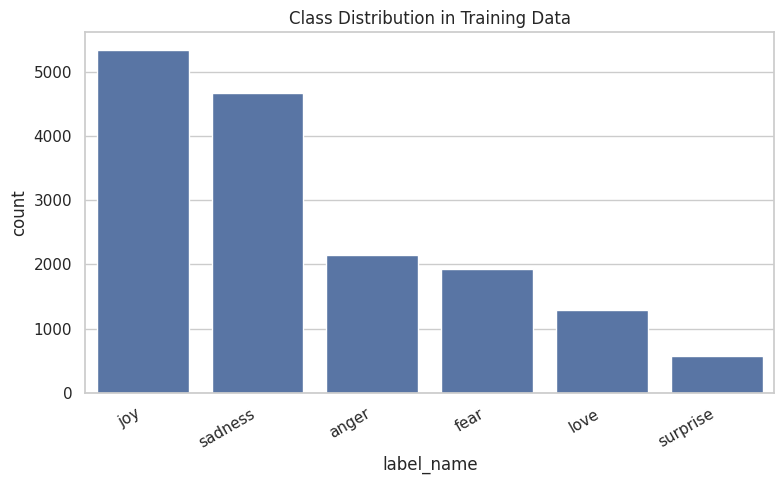

Average word count (train): 19.18


In [5]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras_tuner as kt
from datasets import load_dataset

# Set visualization style
sns.set(style="whitegrid")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the dataset
raw_dataset = load_dataset("mteb/emotion")

# The 'mteb/emotion' dataset labels typically correspond to:
# 0: sadness, 1: joy, 2: love, 3: anger, 4: fear, 5: surprise
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
print("Label names:", label_names)

# Convert to DataFrame
train_df = pd.DataFrame({
    "text": raw_dataset["train"]["text"],
    "label": raw_dataset["train"]["label"]
})
train_df["label_name"] = train_df["label"].map(lambda i: label_names[i])

# Plot class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=train_df,
    x="label_name",
    order=train_df["label_name"].value_counts().index
)
ax.set_title("Class Distribution in Training Data")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Compute average word count
word_counts = train_df["text"].apply(lambda x: len(x.split()))
print(f"Average word count (train): {word_counts.mean():.2f}")

# 3. Deep Dive Data Preprocessing: Tokenization & Padding

Neural models require numeric inputs. For text, we must transform strings into sequences of integers. The key steps are:

1. **Cleaning**: Normalize text (lowercase, remove punctuation).
2. **Tokenization**: Split text into tokens (words).
3. **Vocabulary**: Map words to integer indices. We reserve special tokens:
   - `<PAD>` for padding (index 0)
   - `<UNK>` for out of vocabulary words (index 1)
4. **Numericalization**: Convert tokens to indices.
5. **Padding or truncation**: Ensure equal sequence length for batching.

We implement these steps manually (no pre-built tokenizers), building a vocabulary from the training split and restricting its size to the most frequent words. This ensures reproducibility and demonstrates foundational NLP concepts.

In [6]:
# Hyperparameters for preprocessing.
MAX_VOCAB_SIZE = 20000
MAX_LEN = 80
MIN_FREQ = 2
BATCH_SIZE = 64

def clean_text(text):
    """
    Lowercase text and remove punctuation for basic normalization.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    """
    Tokenize text by simple whitespace splitting.
    """
    return text.split()

def build_vocab(texts, max_vocab_size, min_freq):
    """
    Build a word to index vocabulary from a list of texts.
    """
    counter = Counter()
    for text in texts:
        tokens = tokenize(clean_text(text))
        counter.update(tokens)

    # Reserve indices for special tokens.
    vocab = {"<PAD>": 0, "<UNK>": 1}

    # Add words by frequency, respecting limits.
    for word, freq in counter.most_common(max_vocab_size):
        if freq < min_freq:
            continue
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

def encode_texts(texts, vocab, max_len):
    """
    Convert texts into padded lists of token indices.
    """
    sequences = []
    for text in texts:
        tokens = tokenize(clean_text(text))
        indices = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

        # Truncate if longer than max_len.
        indices = indices[:max_len]

        # Pad with zeros to max_len.
        if len(indices) < max_len:
            indices += [vocab["<PAD>"]] * (max_len - len(indices))

        sequences.append(indices)

    return np.array(sequences, dtype=np.int32)

def prepare_splits(dataset):
    """
    Ensure we have train, validation, and test splits.
    If validation or test is missing, create them from the training split.
    """
    if "validation" in dataset and "test" in dataset:
        return dataset["train"], dataset["validation"], dataset["test"]

    split_1 = dataset["train"].train_test_split(test_size=0.2, seed=42)
    train_split = split_1["train"]
    temp_split = split_1["test"]

    split_2 = temp_split.train_test_split(test_size=0.5, seed=42)
    val_split = split_2["train"]
    test_split = split_2["test"]

    return train_split, val_split, test_split

# Prepare data splits.
train_split, val_split, test_split = prepare_splits(raw_dataset)

# Build vocabulary using only the training split to avoid leakage.
vocab = build_vocab(train_split["text"], MAX_VOCAB_SIZE, MIN_FREQ)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")

# Encode texts into fixed length sequences.
X_train = encode_texts(train_split["text"], vocab, MAX_LEN)
X_val = encode_texts(val_split["text"], vocab, MAX_LEN)
X_test = encode_texts(test_split["text"], vocab, MAX_LEN)

# Convert labels to numpy arrays.
y_train = np.array(train_split["label"], dtype=np.int32)
y_val = np.array(val_split["label"], dtype=np.int32)
y_test = np.array(test_split["label"], dtype=np.int32)

# Create TensorFlow datasets for efficient batching.
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Vocab size: 7386


# 4. Custom Transformer Architecture Design

Our model is a tunable Transformer encoder classifier with five main components:

1. **Token Embedding**: Maps token indices to dense vectors.
2. **Positional Embedding**: Injects word order information into the sequence.
3. **Transformer Encoder Blocks**: Repeated blocks of multi head self attention and a feed forward network, each wrapped with residual connections and layer normalization.
4. **Pooling Layer**: Global average pooling compresses the sequence into a single vector.
5. **Dense Classification Head**: One or two dense layers before the softmax output.

To support Hyperband tuning, we define a Keras Tuner HyperModel. This encapsulates the model architecture and exposes tunable hyperparameters such as embedding size, number of heads, feed forward width, number of Transformer blocks, dropout rate, dense layer width, and learning rate.

**Customization layer details** (what Hyperband can tune):
- Embedding dimension (representation capacity).
- Number of attention heads (parallel attention patterns).
- Feed forward dimension (non linear modeling power).
- Number of Transformer blocks (depth).
- Dropout rate (regularization strength).
- Dense layer units and count (classifier capacity).
- Learning rate (optimization step size).

In [4]:
import tensorflow as tf
import keras_tuner as kt

# Define NUM_CLASSES based on our label names
NUM_CLASSES = len(label_names)

class TransformerEmotionHyperModel(kt.HyperModel):
    def __init__(self, vocab_size, max_len, num_classes):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.num_classes = num_classes

    def build(self, hp):
        embed_dim = hp.Choice("embed_dim", values=[64, 128, 256])
        num_heads = hp.Choice("num_heads", values=[2, 4, 8])
        ff_dim = hp.Int("ff_dim", min_value=128, max_value=512, step=128)
        dropout_rate = hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1)
        learning_rate = hp.Float("lr", min_value=1e-5, max_value=1e-3, sampling="log")

        inputs = tf.keras.Input(shape=(self.max_len,))
        token_embeddings = tf.keras.layers.Embedding(input_dim=self.vocab_size, output_dim=embed_dim)(inputs)
        positions = tf.range(start=0, limit=self.max_len, delta=1)
        position_embeddings = tf.keras.layers.Embedding(input_dim=self.max_len, output_dim=embed_dim)(positions)
        x = token_embeddings + position_embeddings

        num_transformer_blocks = hp.Int("num_transformer_blocks", min_value=1, max_value=3)
        for _ in range(num_transformer_blocks):
            attention_output = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout_rate)(x, x)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
            ffn_output = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
            ffn_output = tf.keras.layers.Dense(embed_dim)(ffn_output)
            ffn_output = tf.keras.layers.Dropout(dropout_rate)(ffn_output)
            x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

        x = tf.keras.layers.GlobalAveragePooling1D()(x)
        num_dense_layers = hp.Int("num_dense_layers", min_value=1, max_value=2)
        for i in range(num_dense_layers):
            dense_units = hp.Int(f"dense_units_{i}", min_value=64, max_value=256, step=64)
            x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
            x = tf.keras.layers.Dropout(dropout_rate)(x)

        outputs = tf.keras.layers.Dense(self.num_classes, activation="softmax")(x)
        model = tf.keras.Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model

hypermodel = TransformerEmotionHyperModel(vocab_size=vocab_size, max_len=MAX_LEN, num_classes=NUM_CLASSES)

In [8]:
import tensorflow as tf

# Define NUM_CLASSES based on our label names
NUM_CLASSES = len(label_names)

def build_best_model(vocab_size, max_len, num_classes):
    embed_dim = 128
    num_heads = 2
    ff_dim = 384
    dropout_rate = 0.1
    learning_rate = 0.00052181

    inputs = tf.keras.Input(shape=(max_len,))
    token_embeddings = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
    positions = tf.range(start=0, limit=max_len, delta=1)
    position_embeddings = tf.keras.layers.Embedding(input_dim=max_len, output_dim=embed_dim)(positions)
    x = token_embeddings + position_embeddings

    num_transformer_blocks = 3
    for _ in range(num_transformer_blocks):
        attention_output = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=dropout_rate)(x, x)
        x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = tf.keras.layers.Dense(ff_dim, activation="relu")(x)
        ffn_output = tf.keras.layers.Dense(embed_dim)(ffn_output)
        ffn_output = tf.keras.layers.Dropout(dropout_rate)(ffn_output)
        x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    num_dense_layers = 1
    for i in range(num_dense_layers):
        dense_units = 192
        x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Create the model directly
best_model = build_best_model(vocab_size=vocab_size, max_len=MAX_LEN, num_classes=NUM_CLASSES)
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 80)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 80, 128)   │    945,408 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 128)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 80, 128)   │    131,968 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 80, 128)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 80, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 80, 384)   │     49,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 80, 128)   │     49,280 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 80, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 80, 128)   │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 80, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 80, 384)   │     49,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 80, 128)   │     49,280 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 80, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 80, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 1,665,222 (6.35 MB)

 Trainable params: 1,665,222 (6.35 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Define early stopping manually since we are skipping the tuner cell
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.5398 - loss: 1.1673 - val_accuracy: 0.8883 - val_loss: 0.3608
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.9022 - loss: 0.2663 - val_accuracy: 0.9100 - val_loss: 0.2275
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.9192 - loss: 0.1916 - val_accuracy: 0.9069 - val_loss: 0.2337
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.9312 - loss: 0.1619 - val_accuracy: 0.9069 - val_loss: 0.2591
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.9451 - loss: 0.1340 - val_accuracy: 0.9009 - val_loss: 0.3082


# 5. Optimization & Training Loop (Hyperband Tuning)

We optimize the model using sparse categorical cross entropy, which is standard for multi class classification. Adam is a widely used optimizer that adapts learning rates for each parameter.

To automatically select strong hyperparameters, we use Keras Tuner Hyperband. Hyperband allocates more training resources to promising configurations while quickly pruning weaker ones, which is especially helpful for Transformer models with multiple depth and width choices.

We will:
- Instantiate a Hyperband tuner with the requested settings.
- Search across the tunable hyperparameters.
- Retrieve the best configuration.
- Train a final model using the best hyperparameters.

In [5]:
# Define Hyperband tuner with the requested signature style.
tuner = kt.Hyperband(
    hypermodel=hypermodel,
    objective="val_accuracy",
    max_epochs=100,
    factor=3,
    hyperband_iterations=1,
    seed=42,
    hyperparameters=None,
    tune_new_entries=True,
    allow_new_entries=True,
    max_retries_per_trial=0,
    max_consecutive_failed_trials=3
)

# Early stopping helps prevent overfitting and speeds up tuning.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Run the hyperparameter search.
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop]
)

# Retrieve the best hyperparameters.
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
for param in best_hp.values:
    print(f"  {param}: {best_hp.get(param)}")

# Build and train the final model with the best hyperparameters.
best_model = tuner.hypermodel.build(best_hp)
history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
128               |128               |embed_dim
2                 |2                 |num_heads
256               |256               |ff_dim
0.2               |0.2               |dropout
0.00059777        |0.00059777        |lr
2                 |2                 |num_transformer_blocks
2                 |2                 |num_dense_layers
64                |64                |dense_units_0
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
4                 |4                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2


KeyboardInterrupt: 

# 6. Model Evaluation & Visualizations

We evaluate the tuned model using several metrics:

- **Accuracy**: Overall proportion of correct predictions.
- **Precision**: Of the predicted positives, how many are correct.
- **Recall**: Of the true positives, how many are found.
- **F1 Score**: Harmonic mean of precision and recall.

Macro averages treat all classes equally, while micro averages weight by support. For imbalanced datasets, macro scores provide a more honest view of performance across minority classes.

We also visualize:
- Training vs validation loss curves.
- Training vs validation accuracy curves.
- Confusion matrix heatmap.
- A full classification report.

Test Loss: 0.2292 | Test Accuracy: 0.9013


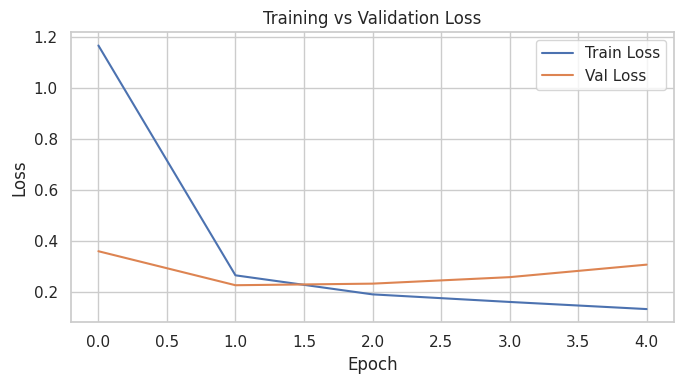

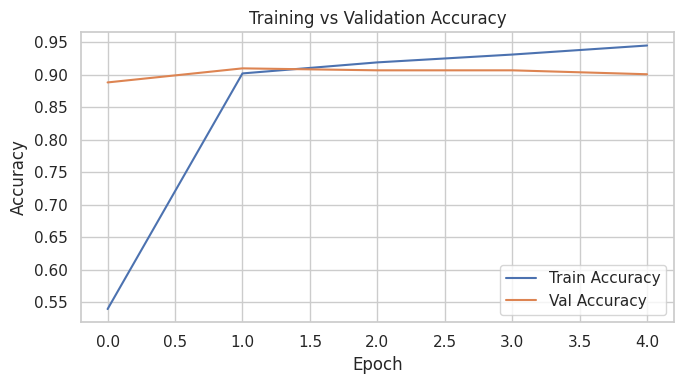

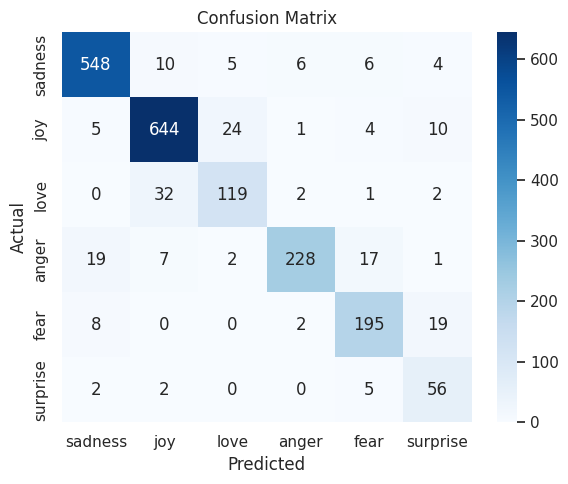

              precision    recall  f1-score   support

     sadness       0.94      0.95      0.94       579
         joy       0.93      0.94      0.93       688
        love       0.79      0.76      0.78       156
       anger       0.95      0.83      0.89       274
        fear       0.86      0.87      0.86       224
    surprise       0.61      0.86      0.71        65

    accuracy                           0.90      1986
   macro avg       0.85      0.87      0.85      1986
weighted avg       0.91      0.90      0.90      1986



In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model on the test set.
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# Generate predictions for detailed metrics.
y_prob = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Plot training vs validation loss.
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot training vs validation accuracy.
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix heatmap.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Classification report.
report = classification_report(y_test, y_pred, target_names=label_names)
print(report)